In [1]:
# CELL 1: SETUP AND ENVIRONMENT
import random
import numpy as np
import matplotlib.pyplot as plt

# Cards: Jack=0, Queen=1, King=2
# J loses to Q and K. Q loses to K, beats J. K beats all.
CARDS = {'J': 0, 'Q': 1, 'K': 2}
REVERSE_CARDS = {0: 'J', 1: 'Q', 2: 'K'}

class KuhnPokerEnv:
    def __init__(self):
        self.deck = [0, 1, 2]
        
    def deal(self):
        """Shuffles and deals one card to each player."""
        random.shuffle(self.deck)
        return self.deck[0], self.deck[1] # P1 card, P2 card
    
    def showdown(self, p1_card, p2_card):
        """Returns 1 if P1 wins, -1 if P2 wins."""
        return 1 if p1_card > p2_card else -1

In [2]:
# CELL 2: THE OPPONENT
class BlufferOpponent:
    def __init__(self, bluff_rate=0.40):
        self.bluff_rate = bluff_rate
        
    def play_as_p1(self, card):
        """
        P1 Strategy:
        - If King (2): Always Bet (Value bet).
        - If Queen (1): Always Check (Pass).
        - If Jack (0): Bet `bluff_rate`% of the time (The Bluff).
        """
        if card == CARDS['K']:
            return 'Bet'
        elif card == CARDS['Q']:
            return 'Pass'
        elif card == CARDS['J']:
            return 'Bet' if random.random() < self.bluff_rate else 'Pass'

In [3]:
# CELL 3: THE BAYESIAN BELIEF ENGINE
class AtomNetBeliefEngine:
    def __init__(self, assumed_bluff_rate=0.50):
        # AToM-Net's internal model of how often the opponent bluffs.
        # It assumes 50% initially, even though the opponent actually uses 40%.
        self.likelihoods = {
            'Bet': {CARDS['J']: assumed_bluff_rate, CARDS['Q']: 0.0, CARDS['K']: 1.0},
            'Pass': {CARDS['J']: 1.0 - assumed_bluff_rate, CARDS['Q']: 1.0, CARDS['K']: 0.0}
        }
        
    def update_beliefs(self, my_card, opp_action):
        """Calculates B_t(theta) over the remaining unknown cards."""
        # Step 1: Establish Priors P(theta)
        # There are 3 cards. I hold one. The opponent must hold one of the other two (50% chance each).
        possible_opp_cards = [c for c in [0, 1, 2] if c != my_card]
        priors = {c: 0.5 for c in possible_opp_cards}
        
        # Step 2: Apply Bayes' Theorem
        posteriors = {}
        total_prob_of_action = 0.0
        
        for c in possible_opp_cards:
            likelihood = self.likelihoods[opp_action][c]
            prob = likelihood * priors[c]
            posteriors[c] = prob
            total_prob_of_action += prob
            
        # Step 3: Normalize to get B_t(theta)
        if total_prob_of_action > 0:
            for c in posteriors:
                posteriors[c] /= total_prob_of_action
                
        return posteriors

--- SIMULATION COMPLETE (10000 Hands) ---
AToM-Net Final Profit: 1367 chips
Learned Opponent Bluff Rate: 0.57


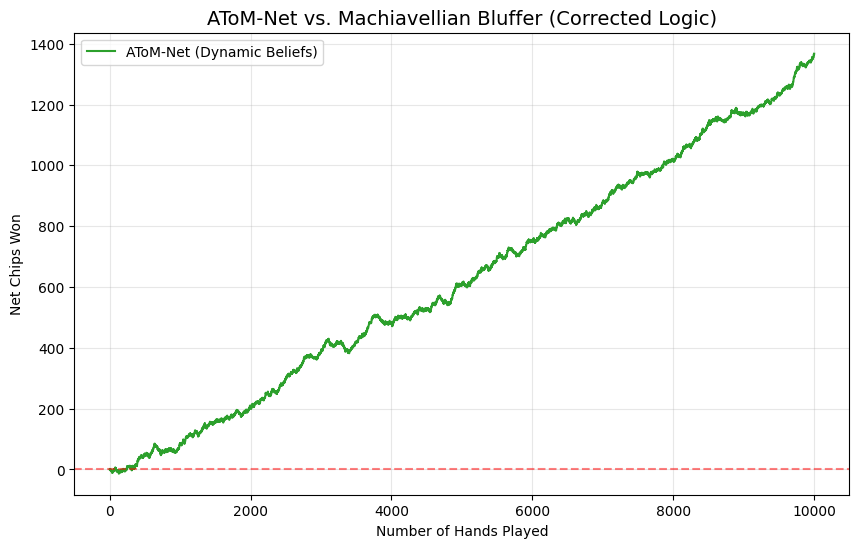

In [7]:
# UPDATED CELL 4: DYNAMIC DECISION ENGINE
class AtomNetDecisionEngine:
    def __init__(self):
        self.belief_engine = AtomNetBeliefEngine(assumed_bluff_rate=0.50)
        self.jacks_seen = 0
        self.bluffs_seen = 0
        
    def learn_from_showdown(self, opp_card, opp_action):
        """Dynamic Theory of Mind: Learns the opponent's true bluff rate."""
        if opp_card == CARDS['J']:
            self.jacks_seen += 1
            if opp_action == 'Bet':
                self.bluffs_seen += 1
            
            # Update the Bayesian prior dynamically
            true_bluff_rate = self.bluffs_seen / self.jacks_seen
            self.belief_engine.likelihoods['Bet'][CARDS['J']] = true_bluff_rate
            self.belief_engine.likelihoods['Pass'][CARDS['J']] = 1.0 - true_bluff_rate

    def play_as_p2(self, my_card, p1_action):
        # FIX 1: NO MORE PACIFIST KINGS
        if p1_action == 'Pass':
            if my_card == CARDS['K']:
                return 'Bet', 1.0 # Extract value!
            else:
                return 'Pass', 0.0 # Just check it down
            
        # FIX 2: DYNAMIC EU CALCULATIONS
        beliefs = self.belief_engine.update_beliefs(my_card, p1_action)
        eu_fold = -1.0
        eu_call = 0.0
        
        for opp_card, prob in beliefs.items():
            if my_card > opp_card:
                eu_call += prob * 2.0  
            else:
                eu_call += prob * -2.0 
                
        if eu_call > eu_fold:
            return 'Call', eu_call
        else:
            return 'Fold', eu_fold

# UPDATED CELL 5: SIMULATION WITH LEARNING
def run_simulation(hands=10000):
    env = KuhnPokerEnv()
    opponent = BlufferOpponent(bluff_rate=0.40) 
    atom_net = AtomNetDecisionEngine()
    
    atom_net_cumulative_profit = [0]
    
    for _ in range(hands):
        p1_card, p2_card = env.deal()
        p1_action = opponent.play_as_p1(p1_card)
        p2_action, _ = atom_net.play_as_p2(p2_card, p1_action)
        
        profit = 0
        showdown_happened = False
        
        # Resolve Hand
        if p1_action == 'Pass' and p2_action == 'Pass':
            profit = 1 if p2_card > p1_card else -1
            showdown_happened = True
        elif p1_action == 'Pass' and p2_action == 'Bet':
            # P1 reacts to our bet. In Kuhn, P1 always folds J, calls Q.
            if p1_card == CARDS['J']: profit = 1 # We win their ante
            else: 
                profit = 2 if p2_card > p1_card else -2
                showdown_happened = True
        elif p1_action == 'Bet' and p2_action == 'Fold':
            profit = -1
        elif p1_action == 'Bet' and p2_action == 'Call':
            profit = 2 if p2_card > p1_card else -2
            showdown_happened = True
            
        # AToM-Net learns from the showdown
        if showdown_happened:
            atom_net.learn_from_showdown(p1_card, p1_action)
                
        new_total = atom_net_cumulative_profit[-1] + profit
        atom_net_cumulative_profit.append(new_total)
        
    print(f"--- SIMULATION COMPLETE ({hands} Hands) ---")
    print(f"AToM-Net Final Profit: {atom_net_cumulative_profit[-1]} chips")
    print(f"Learned Opponent Bluff Rate: {atom_net.belief_engine.likelihoods['Bet'][0]:.2f}")
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(atom_net_cumulative_profit, label='AToM-Net (Dynamic Beliefs)', color='#2ca02c')
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.title('AToM-Net vs. Machiavellian Bluffer (Corrected Logic)', fontsize=14)
    plt.xlabel('Number of Hands Played')
    plt.ylabel('Net Chips Won')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

run_simulation(10000)